In [16]:
import matplotlib
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [17]:
# -----------------------------
# Nodes
# -----------------------------
places = {
    1: ("Pico Aneto", "Peak", 3404),
    2: ("Tuca Alba", "Peak", 3122),
    3: ("Benasque", "Town", 1135),
    4: ("Cerler", "Town", 1530),
    5: ("Ancils", "Town", 1140),
    6: ("Portillón de Benás", "Landmark", 2444),
    7: ("Ski resort", "Snow", 1530),
    8: ("Baños de Benasque", "Resting area", 1550),
    9: ("Hospital de Benasque", "Resting area", 1747),
    10: ("Forau d.aiguallut", "Landmark", 2020),
    11: ("Tres Cascadas", "Landmark", 1900),
    12: ("Salvaguardia", "Peak", 2736),
    13: ("Tuca Maladeta", "Peak", 3312),
    14: ("Cap Llauset", "Refugio", 2425),
    15: ("Ibón Cregüeña", "Lake", 2632),
    16: ("Batisielles", "Lake", 2216),
    17: ("Eriste", "Town", 1089),
    18: ("Ibón Eriste", "Lake", 2407),
    19: ("Tempestades", "Peak", 3289),
    20: ("La Besurta", "Resting area", 1860),
    21: ("La Renclusa", "Refugio", 2160),
    22: ("Escaleta", "Lake", 2630),
    23: ("Mulleres", "Peak", 3013),
    24: ("Salterillo", "Lake", 2460),
    25: ("Tres Barrancos", "Landmark", 1460),
}

# -----------------------------
# Edges
# time in minutes
# -----------------------------
edges = [
    (1, 20, 4*60 + 50),
    (1, 25, 4*60 + 21),
    (2, 8, 4*60 + 20),
    (3, 4, 1*60 + 25),
    (3, 5, 0*60 + 45),
    (3, 8, 0*60 + 0),
    (3, 9, 0*60 + 0),
    (3, 16, 3*60 + 10),
    (3, 17, 0*60 + 0),
    (3, 20, 0*60 + 0),
    (3, 25, 1*60 + 0),
    (4, 5, 1*60 + 30),
    (4, 7, 0*60 + 0),
    (4, 8, 0*60 + 0),
    (4, 9, 0*60 + 0),
    (4, 11, 1*60 + 10),
    (4, 17, 0*60 + 0),
    (4, 20, 0*60 + 0),
    (5, 8, 0*60 + 0),
    (5, 9, 0*60 + 0),
    (5, 17, 0*60 + 0),
    (5, 20, 0*60 + 0),
    (6, 9, 2*60 + 15),
    (6, 12, 1*60 + 0),
    (8, 15, 3*60 + 21),
    (8, 20, 0*60 + 0),
    (9, 20, 0*60 + 0),
    (10, 20, 1*60 + 0),
    (10, 21, 1*60 + 30),
    (13, 20, 4*60 + 12),
    (14, 19, 3*60 + 24),
    (14, 21, 5*60 + 30),
    (16, 18, 2*60 + 18),
    (20, 21, 4*60 + 12),
    (20, 22, 3*60 + 3),
    (21, 24, 1*60 + 21),
    (22, 23, 1*60 + 9),
    (23, 24, 0*60 + 30),
]

In [ ]:
from tsp_planner import (
    plan_tsp_instance,
    plot_feasible_graph,
    plot_best_tsp_subset,
)

result = plan_tsp_instance(
    season="summer",
    expertise="intermediate",
    n_sites=6,
    base_node=3,
    preferred_types=["Peak"],
    require_preferred=False,
    preference_bonus=60,
    max_town_like=2,
    min_degree=2,
    use_time_filter=True,
    altitude_factor=0.05,
    zero_replacement=5
)

print("Best nodes:", result["best_nodes"])
print("Weight matrix shape:", None if result["weight_matrix"] is None else result["weight_matrix"].shape)
print("Weight matrix:")
print(result["weight_matrix"])

print("Labels:")
print(result["matrix_labels"])

plot_feasible_graph(result["G_selected"], base_node=3)

if result["best_nodes"] is not None:
    plot_best_tsp_subset(
        G_selected=result["G_selected"],
        selected_df=result["selected_places_df"],
        best_nodes=result["best_nodes"],
        base_node=3
    )

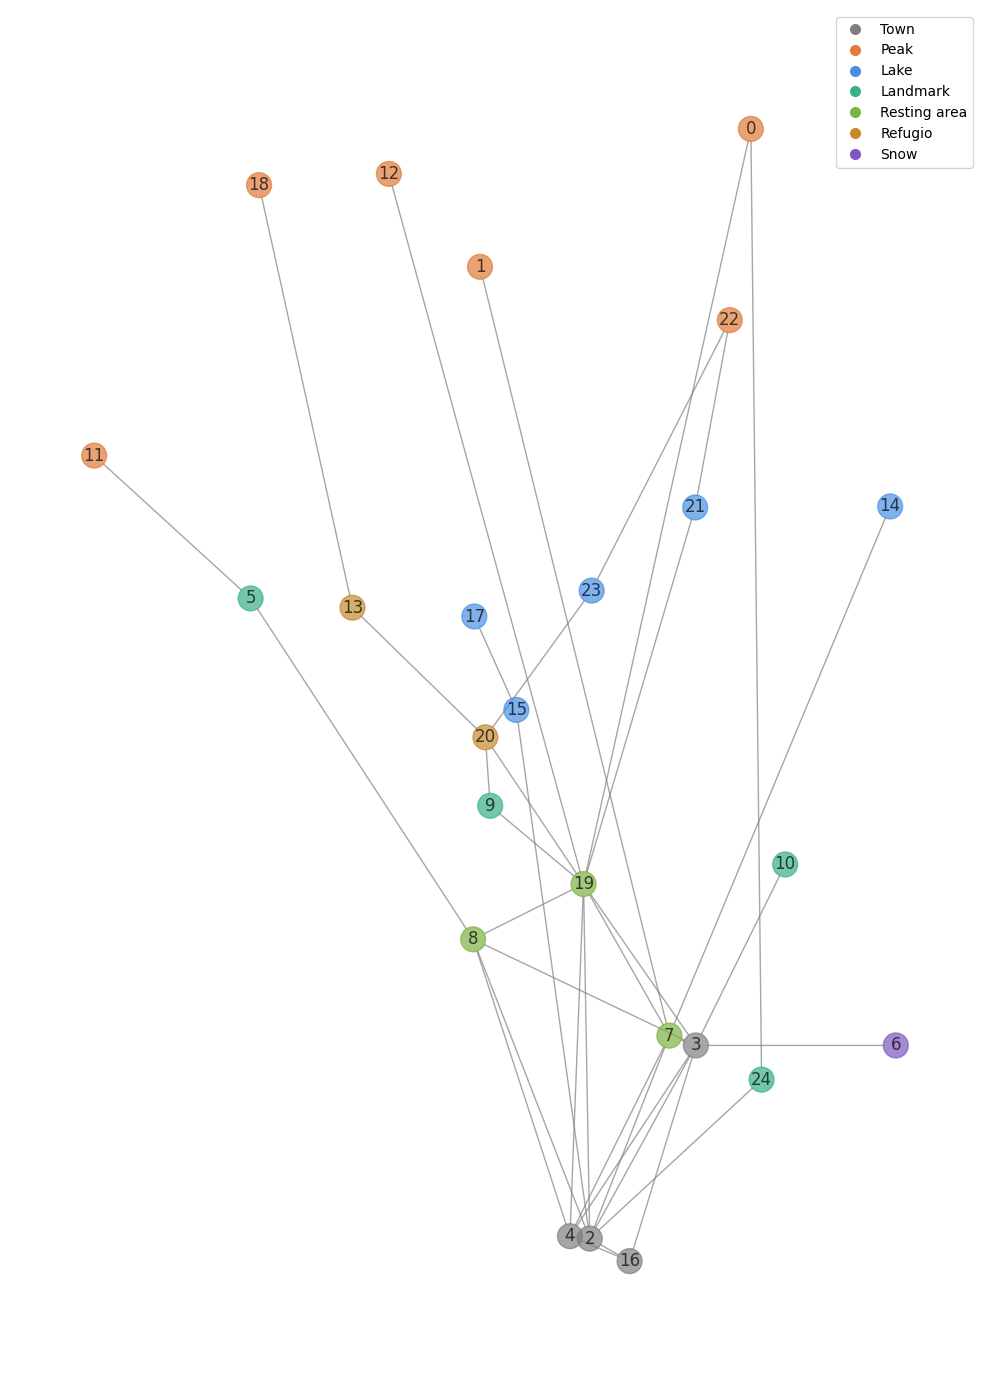

In [18]:
# -----------------------------
# Build graph (rustworkx)
# -----------------------------
G = rx.PyGraph()

place_ids = sorted(places.keys())
id_to_idx = {node_id: idx for idx, node_id in enumerate(place_ids)}
idx_to_id = {idx: node_id for node_id, idx in id_to_idx.items()}

# Keep node payload as name so labels are readable in draw_graph
for node_id in place_ids:
    name, kind, altitude = places[node_id]
    G.add_node(name)

# Edge payload stores time and zero flag
for u, v, t in edges:
    G.add_edge(id_to_idx[u], id_to_idx[v], {"time": float(t), "zero": (t == 0)})

# -----------------------------
# Positions: automatic x, fixed y=altitude
# -----------------------------
base_pos = rx.spring_layout(G, seed=42)
pos = {
    idx: (base_pos[idx][0], places[idx_to_id[idx]][2])
    for idx in range(len(place_ids))
}

# -----------------------------
# Colors by type
# -----------------------------
color_map = {
    "Town": "#7f7f7f",
    "Peak": "#e07b39",
    "Lake": "#4a90e2",
    "Landmark": "#39b185",
    "Resting area": "#7cb342",
    "Refugio": "#c58b2b",
    "Snow": "#7e57c2",
}

node_colors = [
    color_map[places[idx_to_id[idx]][1]]
    for idx in range(len(place_ids))
]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 14))
draw_graph(
    G,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    node_size=320,
    edge_color="gray",
    alpha=0.7,
    ax=ax,
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_ylabel("Altitud")
ax.set_xlabel("")
ax.set_xticks([])
ax.grid(axis="y", linestyle=":", alpha=0.35)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=kind,
           markerfacecolor=color, markersize=9)
    for kind, color in color_map.items()
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [19]:
import heapq
import math

# ============================================
# TSP with QAOA - Binary Encoding
# ============================================
# Each city i has k bits representing its position (0 to N-1)
# Total qubits: N * k where k = ceil(log2(N))
# Much more efficient than one-hot encoding (N*k vs N²)

# 1) Build weighted graph from your current places/edges (rustworkx)
G_tsp = rx.PyGraph()

all_node_ids = sorted(places.keys())
tsp_graph_id_to_idx = {node_id: idx for idx, node_id in enumerate(all_node_ids)}
tsp_graph_idx_to_id = {idx: node_id for node_id, idx in tsp_graph_id_to_idx.items()}

for node_id in all_node_ids:
    G_tsp.add_node(node_id)

weighted_edges = []
for u, v, t in edges:
    w = t / (5 * 60 + 30) + abs(places[v][2] - places[u][2]) / 3404
    weighted_edges.append((u, v, float(w)))
    G_tsp.add_edge(tsp_graph_id_to_idx[u], tsp_graph_id_to_idx[v], float(w))

# 2) Pick 5 connected places (from largest connected component)
components_idx = sorted(rx.connected_components(G_tsp), key=len, reverse=True)
largest_component = sorted([tsp_graph_idx_to_id[i] for i in components_idx[0]])
num_places_tsp = 8
if len(largest_component) < num_places_tsp:
    raise ValueError(f"Largest connected component has {len(largest_component)} nodes, need at least {num_places_tsp}.")

tsp_nodes = largest_component[:num_places_tsp]
N = len(tsp_nodes)
node_to_idx = {node: idx for idx, node in enumerate(tsp_nodes)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

print("TSP nodes selected:", tsp_nodes)

# 3) Metric closure distances (shortest-path distances between selected nodes)
adj = {node_id: [] for node_id in all_node_ids}
for u, v, w in weighted_edges:
    adj[u].append((v, w))
    adj[v].append((u, w))

def dijkstra(source):
    distances = {source: 0.0}
    pq = [(0.0, source)]
    while pq:
        dist_u, u = heapq.heappop(pq)
        if dist_u > distances[u]:
            continue
        for v, w in adj[u]:
            cand = dist_u + w
            if v not in distances or cand < distances[v]:
                distances[v] = cand
                heapq.heappush(pq, (cand, v))
    return distances

sp = {node_id: dijkstra(node_id) for node_id in all_node_ids}

def d(i, j):
    if i == j:
        return 0.0
    return float(sp[i][j])

dist = {(i, j): d(i, j) for i in tsp_nodes for j in tsp_nodes}

# 4) Binary encoding: each city has k bits representing its position
k = math.ceil(math.log2(N)) if N > 1 else 1
n_qubits_tsp = N * k

print(f"Binary encoding: N={N} cities, k={k} bits per city → {n_qubits_tsp} total qubits")
print(f"(vs. {N*N} qubits for one-hot encoding)")

def pos_bits(city_idx, k):
    """Return qubit indices for binary position of city_idx."""
    return [city_idx * k + bit for bit in range(k)]

A = 10.0  # constraint penalty
B = 1.0   # distance weight

qubo_lin = defaultdict(float)
qubo_quad = defaultdict(float)
qubo_const = 0.0

def add_lin(i, c):
    qubo_lin[i] += c

def add_quad(i, j, c):
    if i == j:
        qubo_lin[i] += c
    elif i < j:
        qubo_quad[(i, j)] += c
    else:
        qubo_quad[(j, i)] += c

# Constraint: penalize duplicate positions (all cities must have distinct positions)
for i in range(N):
    for j in range(i + 1, N):
        bits_i = pos_bits(i, k)
        bits_j = pos_bits(j, k)
        # Penalize matching bits: if bit_i[b] == bit_j[b], add penalty
        for b in range(k):
            # x_i + x_j - 2*x_i*x_j penalizes when both are 1
            # (1-x_i) + (1-x_j) - 2*(1-x_i)*(1-x_j) penalizes when both are 0
            # Combined: penalize when they match
            add_lin(bits_i[b], A)
            add_lin(bits_j[b], A)
            add_quad(bits_i[b], bits_j[b], -2.0 * A)

# Objective: minimize cycle distance
# For each consecutive pair in tour, penalize based on their distance
for city_order in range(N):
    ni = tsp_nodes[city_order]
    nj = tsp_nodes[(city_order + 1) % N]
    i = node_to_idx[ni]
    j = node_to_idx[nj]
    
    # Add distance penalty: for each possible position pair, add corresponding penalty
    for pos_i in range(N):
        for pos_j in range(N):
            dist_val = dist[(ni, nj)]
            
            # Encode: "city i at pos_i AND city j at pos_j"
            # Use binary representation matching
            weight = B * dist_val / (N * N)
            
            bits_i = pos_bits(i, k)
            bits_j = pos_bits(j, k)
            
            # Add terms proportional to matching the binary representation
            for b in range(k):
                if ((pos_i >> b) & 1) == 1:
                    add_lin(bits_i[b], weight)
                else:
                    add_lin(bits_i[b], -weight)
                    
                if ((pos_j >> b) & 1) == 1:
                    add_lin(bits_j[b], weight)
                else:
                    add_lin(bits_j[b], -weight)

# 5) QUBO -> Ising -> SparsePauliOp
z_lin = defaultdict(float)
zz = defaultdict(float)
energy_offset = qubo_const

for i, c in qubo_lin.items():
    energy_offset += c / 2.0
    z_lin[i] += -c / 2.0

for (i, j), c in qubo_quad.items():
    energy_offset += c / 4.0
    z_lin[i] += -c / 4.0
    z_lin[j] += -c / 4.0
    zz[(i, j)] += c / 4.0

pauli_terms_tsp = []
for i, c in z_lin.items():
    if abs(c) > 1e-12:
        pauli_terms_tsp.append(("Z", [i], c))
for (i, j), c in zz.items():
    if abs(c) > 1e-12:
        pauli_terms_tsp.append(("ZZ", [i, j], c))

tsp_cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_terms_tsp, n_qubits_tsp).simplify()

print(f"Hamiltonian terms: {len(tsp_cost_hamiltonian.paulis)}")

# 6) QAOA circuit
circuit_tsp = QAOAAnsatz(cost_operator=tsp_cost_hamiltonian, reps=4)
circuit_tsp.measure_all()

TSP nodes selected: [1, 2, 3, 4, 5, 6, 7, 8]
Binary encoding: N=8 cities, k=3 bits per city → 24 total qubits
(vs. 64 qubits for one-hot encoding)
Hamiltonian terms: 84


Best QAOA parameters (binary encoding, coarse grid)
gamma: 1.0471975511965976 beta: 0.5235987755982988
Best decoded tour: [5, 3, 2, 4, 6, 7, 8, 1, 5]
Tour cost: 6.984065092760745


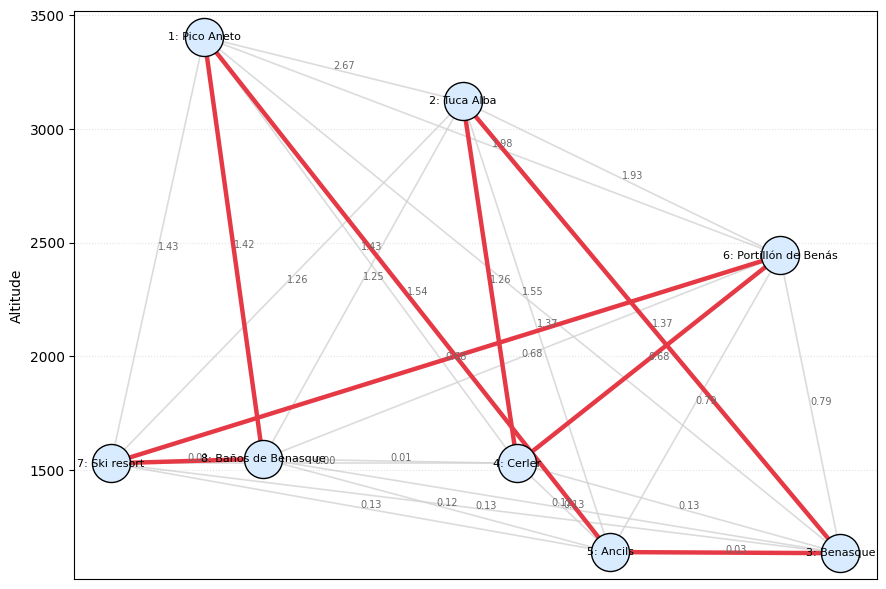

In [22]:

from qiskit import transpile
from qiskit_aer import AerSimulator

# =========================================================
# Run QAOA (local simulator) and decode best TSP path
# =========================================================

sim = AerSimulator()

# Build a no-measure circuit template (reps=1 => 2 parameters)
qaoa_template = QAOAAnsatz(cost_operator=tsp_cost_hamiltonian, reps=1)
qaoa_template_t = transpile(qaoa_template, sim)


def decode_bitstring_to_tour_binary(bitstring: str, N: int, k: int):
    """
    Decode binary-encoded position: each city i occupies k bits.
    Read those bits as binary number to get its tour position.
    """
    bits = bitstring[::-1]  # qubit index order
    
    positions = []
    for city_idx in range(N):
        # Extract k bits for this city
        city_bits = pos_bits(city_idx, k)
        
        # Convert to position value (binary interpretation)
        pos_value = 0
        for b_idx, qubit_idx in enumerate(city_bits):
            if qubit_idx < len(bits):
                pos_value += int(bits[qubit_idx]) * (2 ** b_idx)
        
        # Clamp to valid range [0, N-1]
        pos_value = min(pos_value, N - 1)
        positions.append((pos_value, city_idx))
    
    # Sort by position to get tour order
    positions.sort()
    tour_idx = [city_idx for pos, city_idx in positions]
    
    return tour_idx


def tour_cost_nodes(tour_nodes, dist_map):
    total = 0.0
    for p in range(len(tour_nodes)):
        a = tour_nodes[p]
        b = tour_nodes[(p + 1) % len(tour_nodes)]
        total += dist_map[(a, b)]
    return total


# Fast coarse parameter search
gammas = np.linspace(0.0, np.pi, 4)
betas = np.linspace(0.0, np.pi / 2, 4)

best = {
    "cost": float("inf"),
    "gamma": None,
    "beta": None,
    "tour_nodes": None,
    "bitstring": None,
}

shots = 128

for gamma in gammas:
    for beta in betas:
        bound = qaoa_template_t.assign_parameters([gamma, beta])
        qc = bound.copy()
        qc.measure_all()

        result = sim.run(qc, shots=shots).result()
        counts = result.get_counts()

        best_bit = max(counts, key=counts.get)
        tour_idx = decode_bitstring_to_tour_binary(best_bit, N, k)
        tour_nodes = [idx_to_node[i] for i in tour_idx]
        c = tour_cost_nodes(tour_nodes, dist)

        if c < best["cost"]:
            best.update(
                {
                    "cost": c,
                    "gamma": float(gamma),
                    "beta": float(beta),
                    "tour_nodes": tour_nodes,
                    "bitstring": best_bit,
                }
            )

print("Best QAOA parameters (binary encoding, coarse grid)")
print("gamma:", best["gamma"], "beta:", best["beta"])
print("Best decoded tour:", best["tour_nodes"] + [best["tour_nodes"][0]])
print("Tour cost:", best["cost"])

# -----------------------------
# Plot best tour over selected 5-node metric graph (without networkx)
# -----------------------------
selected_nodes = tsp_nodes

# Build an rx complete graph just to compute a stable spring-layout x-coordinate
H = rx.PyGraph()
for n in selected_nodes:
    H.add_node(n)
for i in range(len(selected_nodes)):
    for j in range(i + 1, len(selected_nodes)):
        u = selected_nodes[i]
        v = selected_nodes[j]
        H.add_edge(i, j, dist[(u, v)])

base_pos = rx.spring_layout(H, seed=42)
pos_tour = {
    selected_nodes[idx]: (base_pos[idx][0], places[selected_nodes[idx]][2])
    for idx in range(len(selected_nodes))
}

tour_nodes = best["tour_nodes"]
route_edges = [(tour_nodes[i], tour_nodes[(i + 1) % len(tour_nodes)]) for i in range(len(tour_nodes))]
route_edges_undirected = {tuple(sorted(e)) for e in route_edges}

plt.figure(figsize=(9, 6))

# Draw all pair edges (metric closure), highlighting route edges
for i in range(len(selected_nodes)):
    for j in range(i + 1, len(selected_nodes)):
        u = selected_nodes[i]
        v = selected_nodes[j]
        x = [pos_tour[u][0], pos_tour[v][0]]
        y = [pos_tour[u][1], pos_tour[v][1]]
        if tuple(sorted((u, v))) in route_edges_undirected:
            plt.plot(x, y, linewidth=3.2, color="#e63946", zorder=2)
        else:
            plt.plot(x, y, linewidth=1.2, color="lightgray", alpha=0.8, zorder=1)

        mx = 0.5 * (x[0] + x[1])
        my = 0.5 * (y[0] + y[1])
        plt.text(mx, my, f"{dist[(u, v)]:.2f}", fontsize=7, color="dimgray")

# Draw nodes and labels
xs = [pos_tour[n][0] for n in selected_nodes]
ys = [pos_tour[n][1] for n in selected_nodes]
plt.scatter(xs, ys, s=750, c="#d9ecff", edgecolors="black", zorder=3)

for n in selected_nodes:
    plt.text(
        pos_tour[n][0],
        pos_tour[n][1],
        f"{n}: {places[n][0]}",
        fontsize=8,
        ha="center",
        va="center",
        zorder=4,
    )

plt.ylabel("Altitude")
plt.xticks([])
plt.grid(axis="y", linestyle=":", alpha=0.35)
plt.tight_layout()
plt.show()